# A1 — Two-Bars BB Visual Comparison

**Purpose:** compile and compare the existing Assignment 1 visuals for **BB_01**, **BB_02**, and **BB_03**.

(1) **scan** → find exported PNG visuals  
(2) **compare** → build contact sheets and quantitative dashboard  
(3) **apply** → save a clean comparison package for the repository

This notebook does **not** regenerate graph geometry or alter Assignment 1 datasets.


In [1]:
# setup00 — environment and repository path
import os, sys, subprocess, importlib.util
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REQUIRED = {
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "PIL": "Pillow",
}

missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageDraw

COLAB_REPO = "/content/GML_Edu"
DRIVE_REPO = "/content/drive/MyDrive/GML_Edu"
LOCAL_REPO = "D:/GitHub/GML_Edu"  # edit only if your local folder differs

if IN_COLAB:
    PROJECT_ROOT = Path(COLAB_REPO if os.path.isdir(COLAB_REPO)
                        else DRIVE_REPO if os.path.isdir(DRIVE_REPO)
                        else COLAB_REPO)
else:
    PROJECT_ROOT = Path(LOCAL_REPO)

print(f"Runtime          : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Python executable : {sys.executable}")
print(f"PROJECT_ROOT     : {PROJECT_ROOT}")
print(f"Repository exists: {PROJECT_ROOT.is_dir()}")

if not PROJECT_ROOT.is_dir():
    raise FileNotFoundError(f"Repository not found: {PROJECT_ROOT}")


Runtime          : Local
Python executable : d:\AI\envs\genai\python.exe
PROJECT_ROOT     : D:\GitHub\GML_Edu
Repository exists: True


In [2]:
# paths and layout selector
LAYOUTS = ("BB_01", "BB_02", "BB_03")

A1_ROOT = PROJECT_ROOT / "assignments" / "assignment_01_graph_generation"
VISUALS_ROOT = A1_ROOT / "04_visuals"
DATASET_ROOT = A1_ROOT / "03_graph_dataset"

COMPARE_ROOT = VISUALS_ROOT / "BB_comparison"
COMPARE_ROOT.mkdir(parents=True, exist_ok=True)

print("Visual source root:", VISUALS_ROOT)
print("Comparison output :", COMPARE_ROOT)


Visual source root: D:\GitHub\GML_Edu\assignments\assignment_01_graph_generation\05_visuals
Comparison output : D:\GitHub\GML_Edu\assignments\assignment_01_graph_generation\05_visuals\BB_comparison


## 1. Scan available visuals

The notebook accepts any PNG names. It groups visuals by their filename suffix after an optional numeric prefix, for example:

```text
01_graph_overview.png
02_graph_nodes.png
```

The same visual type is compared across BB layouts when its normalized filename matches.


In [3]:
# scan all PNG visuals
def normalized_visual_key(path: Path) -> str:
    stem = path.stem.lower()
    stem = stem.replace("bb_01", "").replace("bb_02", "").replace("bb_03", "")
    stem = stem.strip("_- ")
    stem = __import__("re").sub(r"^\d+[ _-]*", "", stem)
    return stem or path.stem.lower()

records = []
for layout_id in LAYOUTS:
    folder = VISUALS_ROOT / layout_id
    if not folder.is_dir():
        print(f"WARNING: missing visual folder → {folder}")
        continue
    for p in sorted(folder.glob("*.png")):
        records.append({
            "layout_id": layout_id,
            "filename": p.name,
            "visual_key": normalized_visual_key(p),
            "path": str(p),
            "bytes": p.stat().st_size,
        })

gallery = pd.DataFrame(records)
display(gallery[["layout_id", "filename", "visual_key", "bytes"]].sort_values(["visual_key", "layout_id"])
        if not gallery.empty else gallery)

gallery.to_csv(COMPARE_ROOT / "visual_gallery_manifest.csv", index=False)
print(f"Found {len(gallery)} PNG files.")
print(f"Saved: {COMPARE_ROOT / 'visual_gallery_manifest.csv'}")


,layout_id,filename,visual_key,bytes
4,BB_01,BB_01_05_degree_distribution.png,degree_distribution,76257
9,BB_02,BB_02_05_degree_distribution.png,degree_distribution,80473
14,BB_03,BB_03_05_degree_distribution.png,degree_distribution,73526
3,BB_01,BB_01_04_graph_by_apartment.png,graph_by_apartment,203218
8,BB_02,BB_02_04_graph_by_apartment.png,graph_by_apartment,219239
13,BB_03,BB_03_04_graph_by_apartment.png,graph_by_apartment,198629
2,BB_01,BB_01_03_graph_by_physical_floor.png,graph_by_physical_floor,220656
7,BB_02,BB_02_03_graph_by_physical_floor.png,graph_by_physical_floor,235920
12,BB_03,BB_03_03_graph_by_physical_floor.png,graph_by_physical_floor,215028
1,BB_01,BB_01_02_graph_by_type.png,graph_by_type,232395


Found 15 PNG files.
Saved: D:\GitHub\GML_Edu\assignments\assignment_01_graph_generation\05_visuals\BB_comparison\visual_gallery_manifest.csv


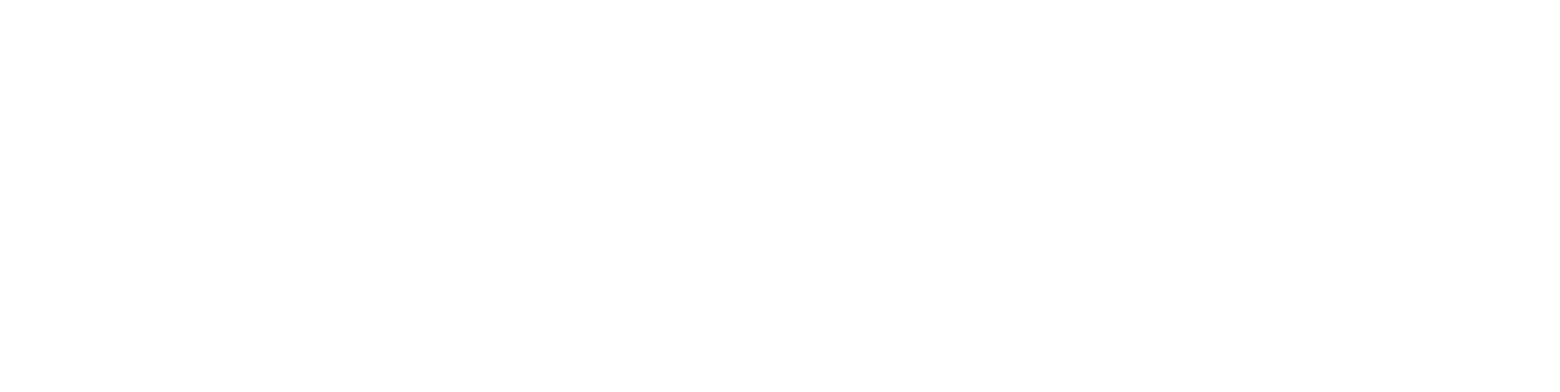

Saved: compare_degree_distribution.png


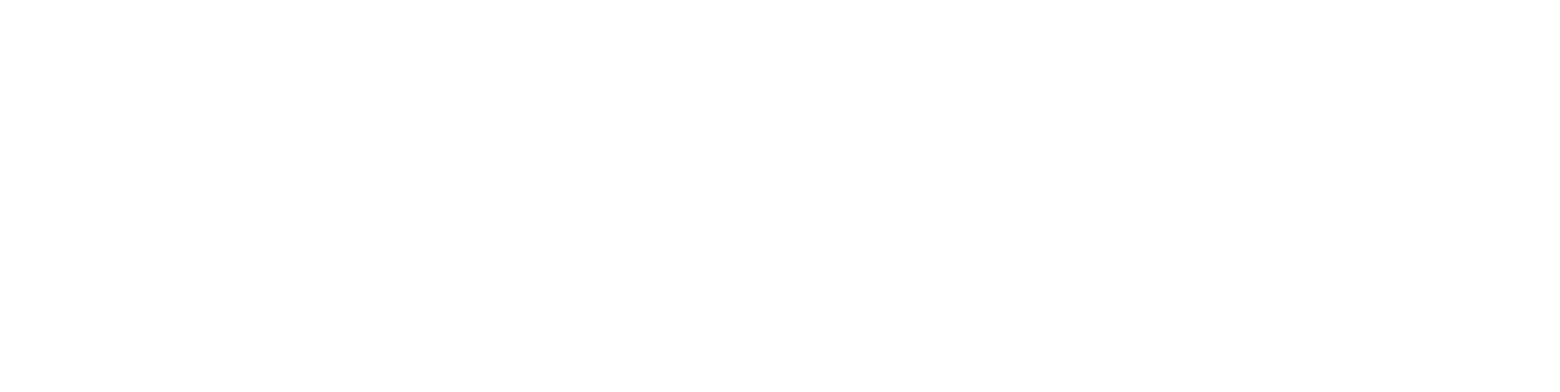

Saved: compare_graph_by_apartment.png


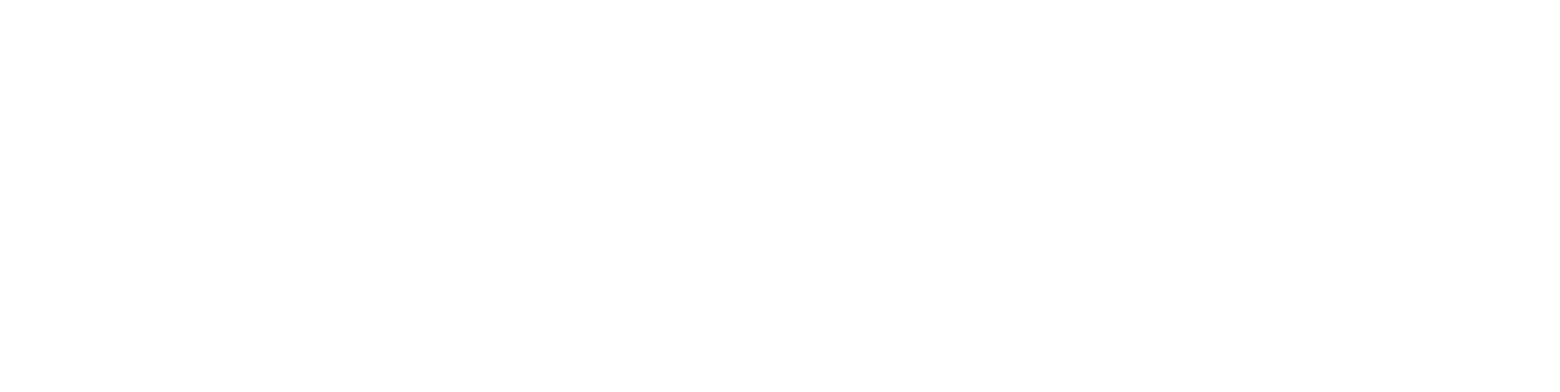

Saved: compare_graph_by_physical_floor.png


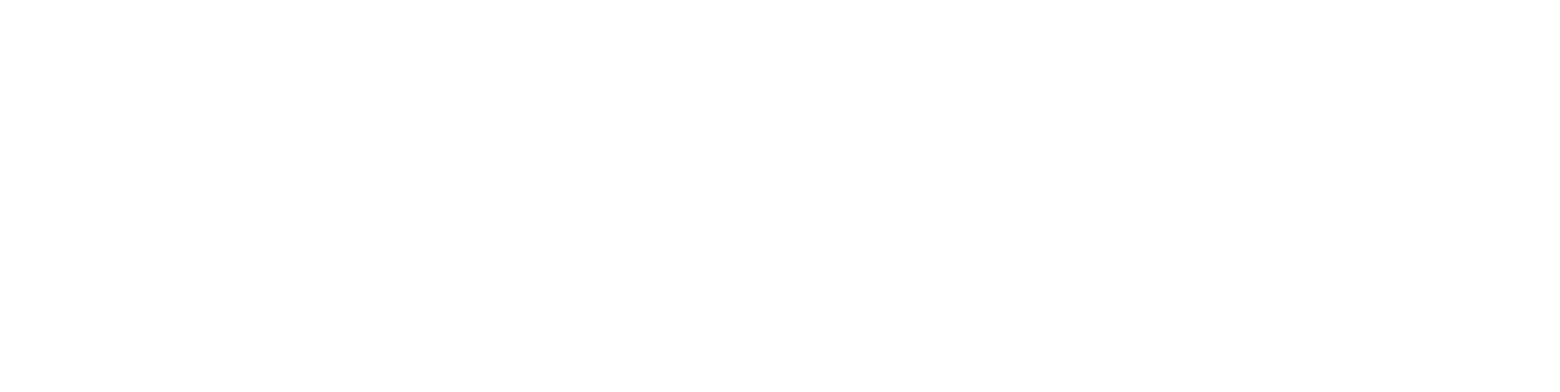

Saved: compare_graph_by_type.png


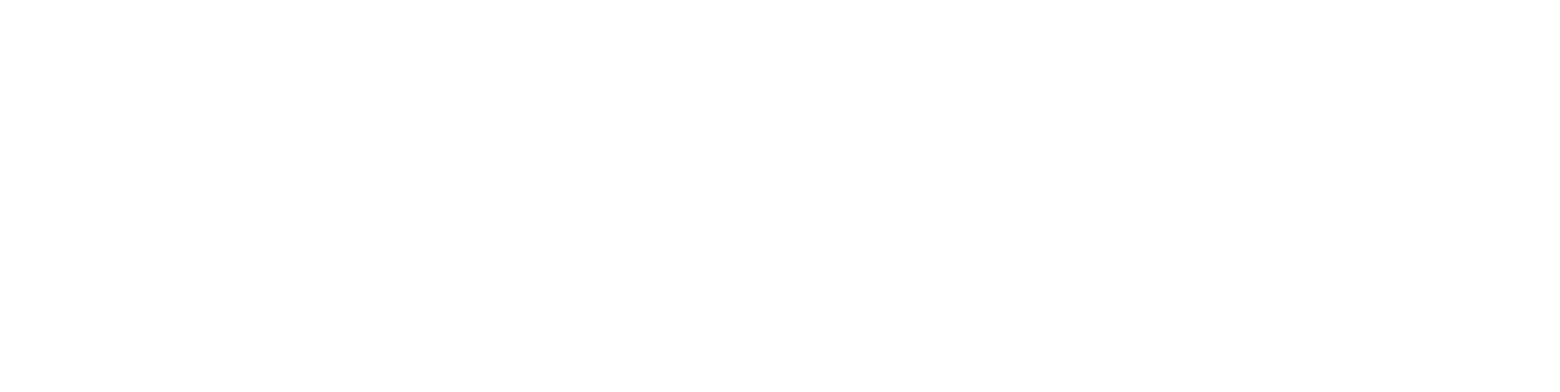

Saved: compare_spatial_adjacency_graph.png


In [4]:
# build comparison contact sheets
if gallery.empty:
    raise FileNotFoundError(
        "No PNG visuals found. First create or copy visuals into "
        "assignments/assignment_01_graph_generation/04_visuals/BB_01, BB_02, and BB_03."
    )

def add_label(im, label, height=42):
    band = Image.new("RGB", (im.width, height), "white")
    draw = ImageDraw.Draw(band)
    draw.text((12, 12), label, fill="black")
    return Image.new("RGB", (im.width, im.height + height), "white")

def labelled_thumbnail(path, label, size=(520, 350)):
    im = Image.open(path).convert("RGB")
    im.thumbnail(size)
    canvas = Image.new("RGB", size, "white")
    x = (size[0] - im.width) // 2
    y = (size[1] - im.height) // 2
    canvas.paste(im, (x, y))
    return add_label(canvas, label)

for visual_key, group in gallery.groupby("visual_key", sort=True):
    tiles = []
    for layout_id in LAYOUTS:
        match = group[group["layout_id"] == layout_id]
        if match.empty:
            blank = Image.new("RGB", (520, 392), "white")
            ImageDraw.Draw(blank).text((12, 12), f"{layout_id} — missing", fill="black")
            tiles.append(blank)
        else:
            row = match.sort_values("filename").iloc[0]
            tiles.append(labelled_thumbnail(row["path"], f"{layout_id} — {row['filename']}"))
    width = sum(t.width for t in tiles)
    height = max(t.height for t in tiles)
    sheet = Image.new("RGB", (width, height), "white")
    x = 0
    for tile in tiles:
        sheet.paste(tile, (x, 0))
        x += tile.width
    output = COMPARE_ROOT / f"compare_{visual_key}.png"
    sheet.save(output, quality=95)
    display(sheet)
    print("Saved:", output.name)


## 2. Compare graph scale and node roles

This uses Assignment 1 `nodes.csv` and `edges.csv` when available.  
It is a visual summary, not a substitute for Assignment 2 metrics.


In [5]:
# load available graph datasets
summary_rows = []
role_rows = []

for layout_id in LAYOUTS:
    nodes_path = DATASET_ROOT / layout_id / "nodes.csv"
    edges_path = DATASET_ROOT / layout_id / "edges.csv"

    if not nodes_path.exists() or not edges_path.exists():
        print(f"WARNING: missing graph CSVs for {layout_id}")
        continue

    nodes = pd.read_csv(nodes_path)
    edges = pd.read_csv(edges_path)

    summary_rows.append({
        "layout_id": layout_id,
        "nodes": len(nodes),
        "edges": len(edges),
        "physical_floors": nodes["physical_floor"].nunique() if "physical_floor" in nodes else None,
        "apartments": nodes["apartment_id"].nunique() if "apartment_id" in nodes else None,
    })

    if "node_role" in nodes:
        counts = nodes["node_role"].value_counts()
        for role, count in counts.items():
            role_rows.append({"layout_id": layout_id, "node_role": role, "count": count})

summary_df = pd.DataFrame(summary_rows)
role_df = pd.DataFrame(role_rows)

display(summary_df)
display(role_df.pivot(index="node_role", columns="layout_id", values="count").fillna(0).astype(int)
        if not role_df.empty else role_df)

summary_df.to_csv(COMPARE_ROOT / "BB_graph_scale_summary.csv", index=False)
role_df.to_csv(COMPARE_ROOT / "BB_node_role_counts.csv", index=False)


,layout_id,nodes,edges,physical_floors,apartments
0,BB_01,175,388,2,31
1,BB_02,381,858,3,71
2,BB_03,141,303,3,23


layout_id,BB_01,BB_02,BB_03
node_role,,,
core,2,3,3
corridor,12,18,18
room,161,360,120


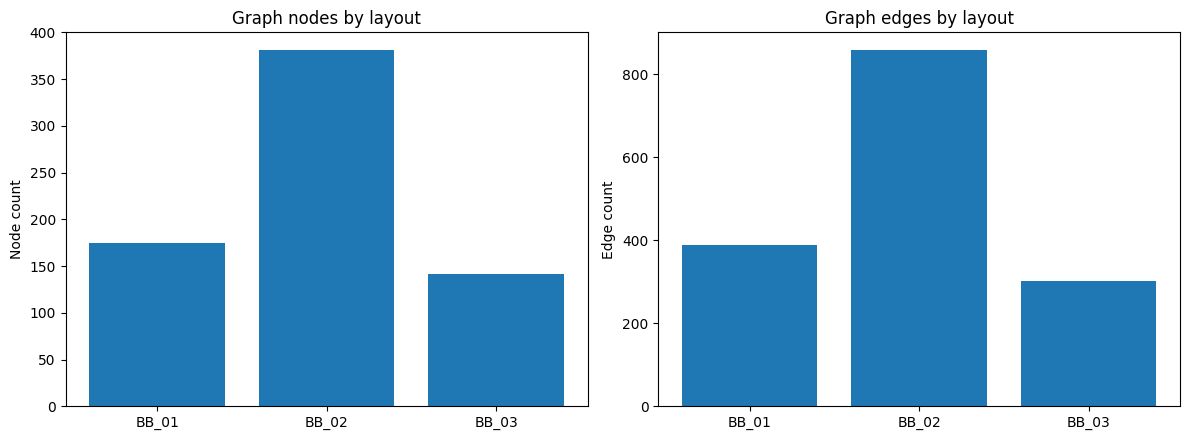

Saved: D:\GitHub\GML_Edu\assignments\assignment_01_graph_generation\05_visuals\BB_comparison\BB_graph_scale_dashboard.png


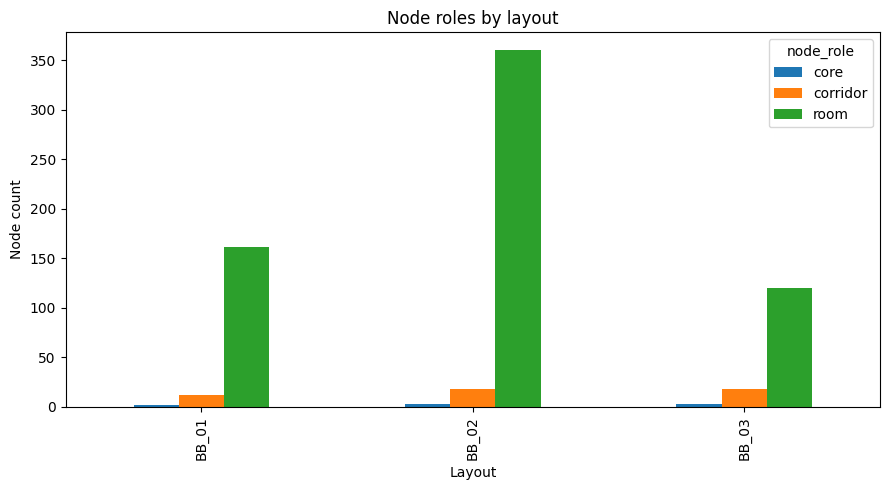

Saved: D:\GitHub\GML_Edu\assignments\assignment_01_graph_generation\05_visuals\BB_comparison\BB_node_role_comparison.png


In [6]:
# generate graph-scale dashboard
if summary_df.empty:
    print("No graph CSVs available. Contact sheets are still complete.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].bar(summary_df["layout_id"], summary_df["nodes"])
    axes[0].set_title("Graph nodes by layout")
    axes[0].set_ylabel("Node count")

    axes[1].bar(summary_df["layout_id"], summary_df["edges"])
    axes[1].set_title("Graph edges by layout")
    axes[1].set_ylabel("Edge count")

    fig.tight_layout()
    out = COMPARE_ROOT / "BB_graph_scale_dashboard.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

if not role_df.empty:
    pivot = role_df.pivot(index="layout_id", columns="node_role", values="count").fillna(0)
    ax = pivot.plot(kind="bar", figsize=(9, 5))
    ax.set_title("Node roles by layout")
    ax.set_xlabel("Layout")
    ax.set_ylabel("Node count")
    plt.tight_layout()
    out = COMPARE_ROOT / "BB_node_role_comparison.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


## 3. Repository evidence

Add the generated folder to the Assignment 1 repository visual evidence:

```text
04_visuals/
├── BB_01/
├── BB_02/
├── BB_03/
└── BB_comparison/
    ├── visual_gallery_manifest.csv
    ├── compare_*.png
    ├── BB_graph_scale_summary.csv
    ├── BB_node_role_counts.csv
    ├── BB_graph_scale_dashboard.png
    └── BB_node_role_comparison.png
```

⚠ **Interpretation rule:** these images compare generated variants.  
They do not replace the required graph-analysis metrics in Assignment 2.
